In [1]:
"""
PID controller class

"""

import numpy as np


class pid_ctrl():
    def __init__(self, kp, ki, kd, dt, dim):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.dt = dt

        self.int = np.zeros(dim)
        self.prev_error = np.zeros(dim)
        self.prev_input = np.zeros(dim)  # For derivative on measurement

        self.saturation_thres = np.ones(dim) * 1000
        self.cross_zero_thres = np.ones(dim) * 0.1
    
    def anti_saturation(self, error, cross_zero_reset=False):
        # Apply saturation thresholds element-wise
        self.int = np.minimum(self.int, self.saturation_thres)
        self.int = np.maximum(self.int, -self.saturation_thres)

        if cross_zero_reset:
            # Reset integral when error crosses zero (element-wise)
            zero_cross_mask = np.abs(error) < self.cross_zero_thres
            self.int[zero_cross_mask] = np.zeros_like(self.int)[zero_cross_mask]

    def control(self, ref, input):
        error = ref - input

        # Proportional term
        p = self.kp * error

        # Integral term with dt factor
        self.int += error * self.dt
        self.anti_saturation(error)  # Anti-windup
        i = self.ki * self.int

        # Derivative term (on measurement to avoid derivative kicks)
        d = -self.kd * (input - self.prev_input) / self.dt

        if isinstance(input, np.ndarray):
            self.prev_input = input.copy()
            self.prev_error = error.copy()
        else:
            self.prev_input = input
            self.prev_error = error

        return p + i + d


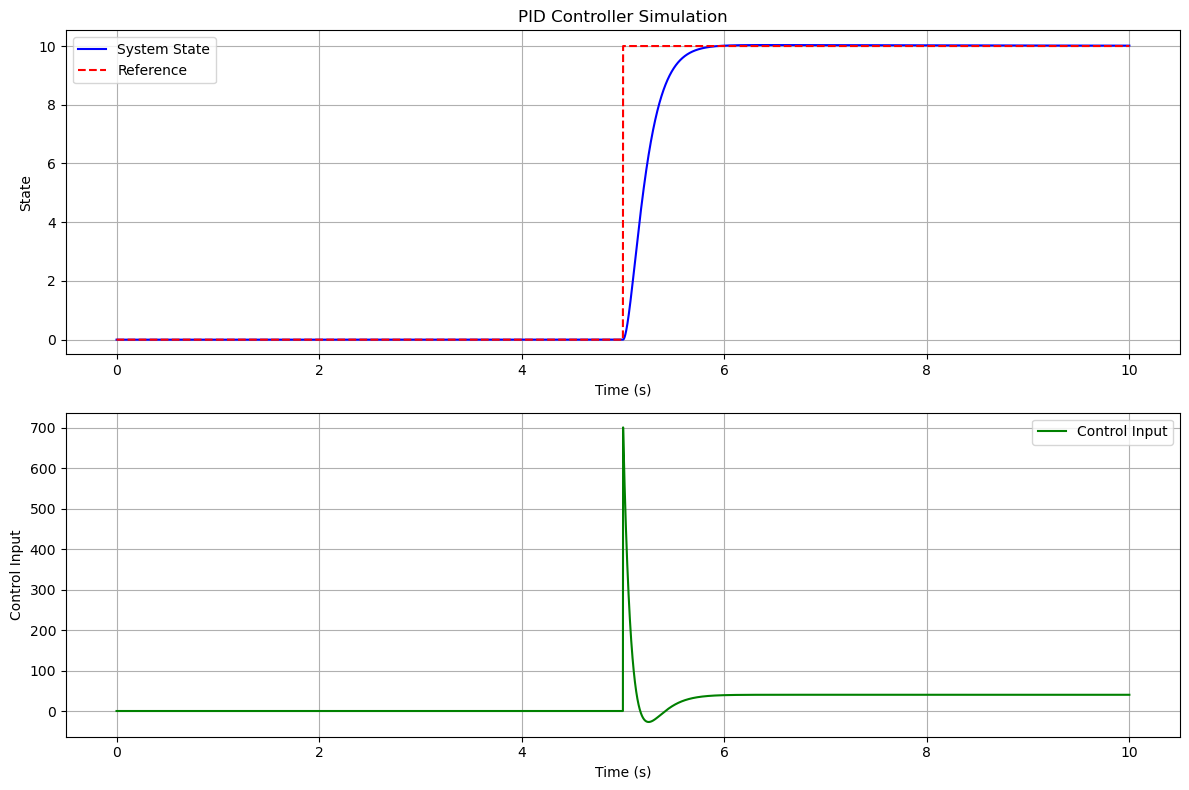

In [2]:
# Copilot Generated
"""
PID Controller Simulation
Demonstrates the PID controller with various dynamic systems
"""
import matplotlib.pyplot as plt
import time

def second_order_system(state, u, dt):
    """
    mx'' + bx' + kx = F

    State-space form:
    x1' = x2
    x2' = (F - bx2 - kx1)/m

    state[0] = x (pos)
    state[1] = x' (vel)
    """
    m = 1.0
    b = 2.0
    k = 4.0
    
    dx1 = state[1]
    dx2 = (u - b * state[1] - k * state[0]) / m
    
    new_state = state.copy()
    new_state[0] += dx1 * dt
    new_state[1] += dx2 * dt
    
    return new_state

# Simulation parameters
dt = 0.001  # Time step
sim_time = 10.0  # Total simulation time
time_steps = int(sim_time / dt)

# PID controller parameters
kp = 70.0
ki = 18.0
kd = 15.0

# Initialize simulation
state = [0.0, 0.0]  # Initial state [pos, vel]
reference = 0.0  # Target pos

# For step reference change mid-simulation
reference_change_time = 5.0
new_reference = 10.0

# Create controller
controller = pid_ctrl(kp, ki, kd, dt, dim=1)

# Log data for plotting
time_log = []
state_log = []
reference_log = []
control_log = []

# Run simulation
for i in range(time_steps):
    current_time = i * dt
    
    # Change reference halfway through simulation
    if current_time >= reference_change_time:
        reference = new_reference
    
    # Calculate control input using PID controller
    control_input = controller.control(reference, state[0])[0]
    
    # Apply control to system
    state = second_order_system(state, control_input, dt)
    
    # Log data
    time_log.append(current_time)
    state_log.append(state[0])
    reference_log.append(reference)
    control_log.append(control_input)

# Plot results
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(time_log, state_log, 'b-', label='System State')
plt.plot(time_log, reference_log, 'r--', label='Reference')
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('State')
plt.title('PID Controller Simulation')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time_log, control_log, 'g-', label='Control Input')
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Control Input')
plt.legend()

plt.tight_layout()
plt.show()
